In [3]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'analysis.ipynb', 'Housing.csv']


In [4]:
#Task 1 — Data Loading & Exploration

In [5]:
#Load the CSV file using Pandas
import pandas as pd
df = pd.read_csv("Housing.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [6]:
#Display the first 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [7]:
#Check how many rows and columns are there
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape: (545, 13)
Rows: 545
Columns: 13


In [8]:
#displaying column names
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [9]:
#Identify which column is the target (Price) and which are features
target = "price"
features = df.columns.drop("price")
print("Target Column:")
print(target)
print("\nFeature Columns:")
print(features)

Target Column:
price

Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [10]:
#Check for missing values in each column
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [11]:
#Task 2 — Data Cleaning

In [12]:
# Handle missing values (fill or drop, whichever fits the column)
# Missing values
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [14]:
#Handle Missing Values(fill or drop, whichever fits the column)
print(df.fillna(df.mode().iloc[0], inplace=True))

print(df.dropna(inplace=True))

None
None


In [15]:
#Remove duplicate rows, if any
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after removal:", df.duplicated().sum())

Duplicates: 0
Duplicates after removal: 0


In [17]:
#Convert any categorical columns 
#(e.g., yes/no fields) into numeric form using one-hot encoding"""
#Columns such as:mainroad, guestroom, basement, hotwaterheating, airconditioning,
#prefarea, furnishingstatus
df = pd.get_dummies(df, drop_first=True)
#for checking
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [18]:
#Keep only the columns that are meaningful for predicting price
X = df.drop("price", axis=1)
y = df["price"]

In [19]:
#Task 3 — Model Building

In [20]:
#Import Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

In [21]:
# Split the data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [22]:
#Train a Linear Regression model to predict house price
#Train Model
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
#Prediction
y_pred_lr = lr.predict(X_test)

In [24]:
#Evaluate it using MAE, RMSE, and R² Score
#Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE =", mae_lr)
print("RMSE =", rmse_lr)
print("R² =", r2_lr)

Linear Regression Results
MAE = 970043.4039201637
RMSE = 1324506.9600914384
R² = 0.6529242642153185


In [25]:
#Train a second model — Random Forest Regressor — 
#and compare its performance to the Linear Regression model
#Train Model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
#Prediction
y_pred_rf = rf.predict(X_test)

In [27]:
#Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE =", mae_rf)
print("RMSE =", rmse_rf)
print("R² =", r2_rf)

Random Forest Results
MAE = 1021546.0353211008
RMSE = 1400565.9728553821
R² = 0.611918531405699


In [28]:
#Compare Models
print("Linear Regression R² :", r2_lr)
print("Random Forest R² :", r2_rf)

Linear Regression R² : 0.6529242642153185
Random Forest R² : 0.611918531405699


In [29]:
#Task 4 — Visualization (Minimum 3 charts)

In [32]:
#Import Libraries
import matplotlib.pyplot as plt
import seaborn as sns

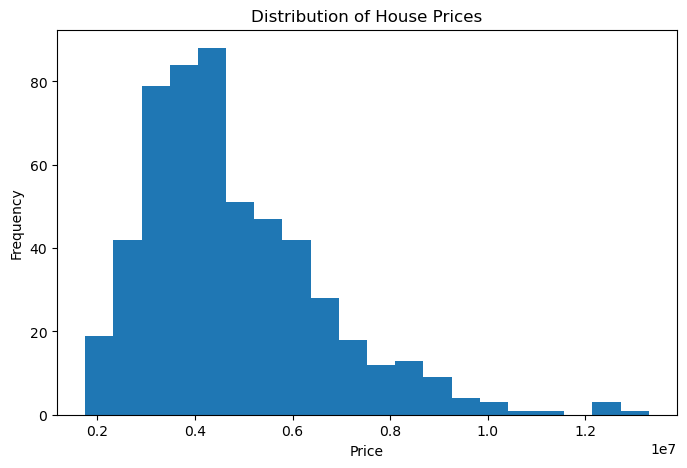

In [33]:
#Chart 1: Histogram showing the distribution of house prices
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=20)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("price_distribution.png")

plt.show()

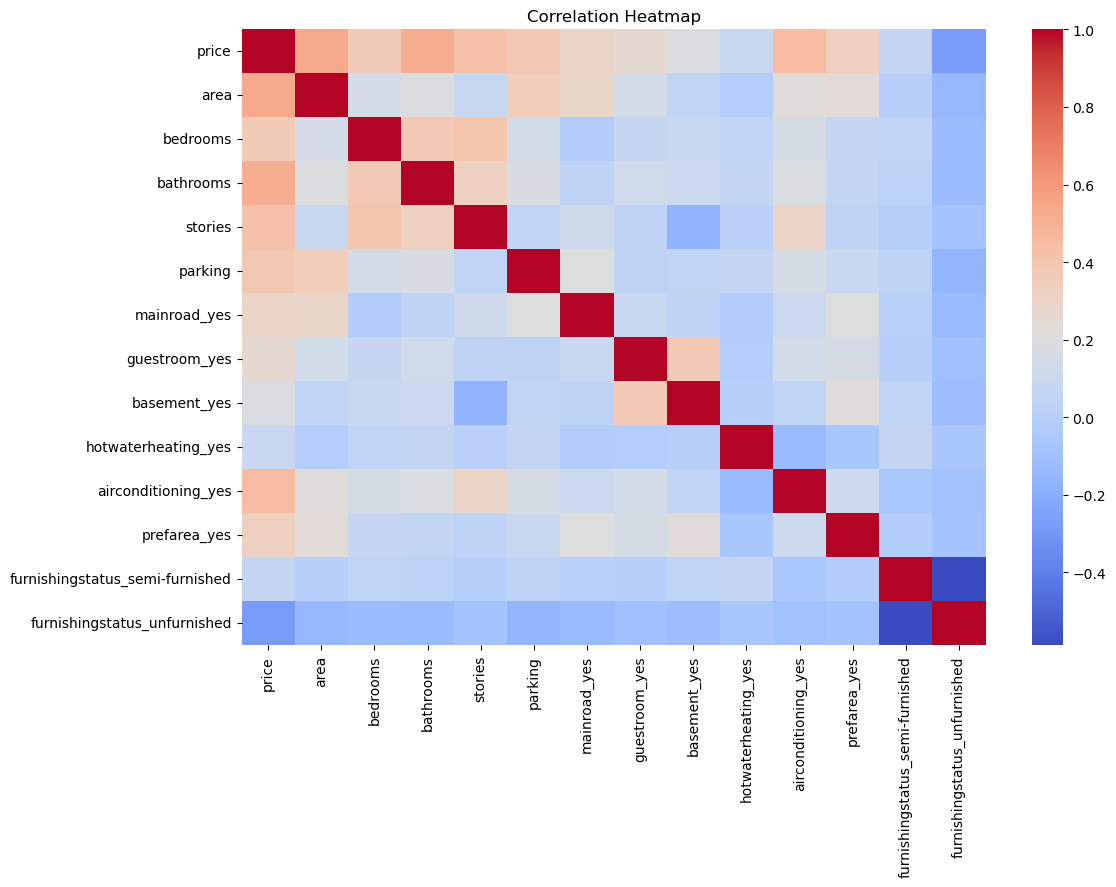

In [34]:
#Chart 2: Correlation heatmap showing which features relate most strongly to price
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")

plt.show()

In [35]:
#Chart 3: A chart of your own choice — be creative! 
#(e.g., actual vs. predicted price scatter plot, price vs. area scatter plot, etc.)

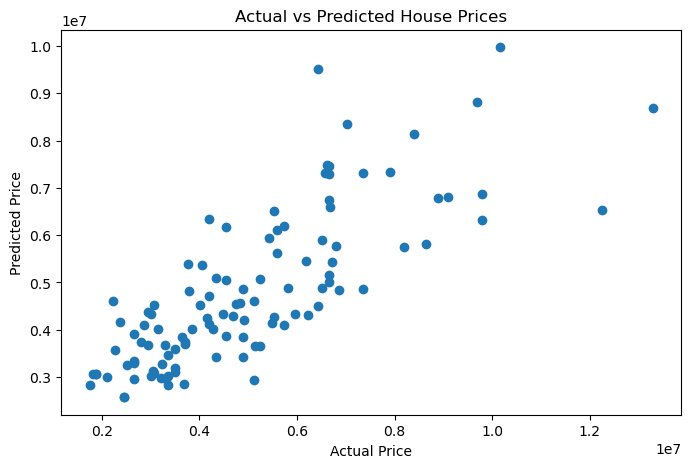

In [36]:
#Actual vs Predicted Price
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig("actual_vs_predicted.png")

plt.show()

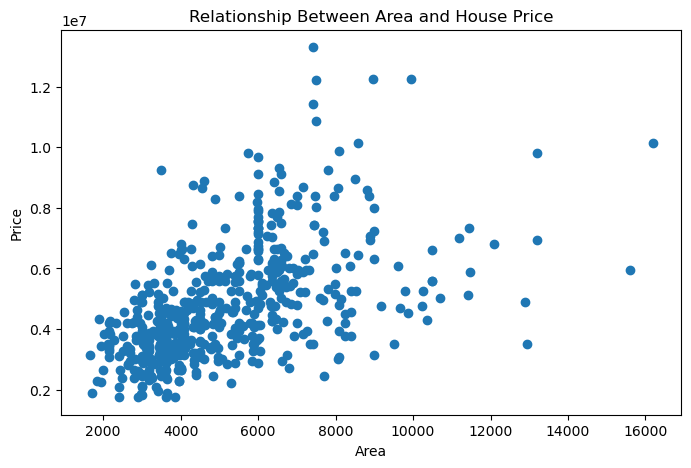

In [37]:
#Price vs Area Scatter Plot
plt.figure(figsize=(8,5))

plt.scatter(df["area"], df["price"])

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Relationship Between Area and House Price")

plt.savefig("price_vs_area.png")

plt.show()

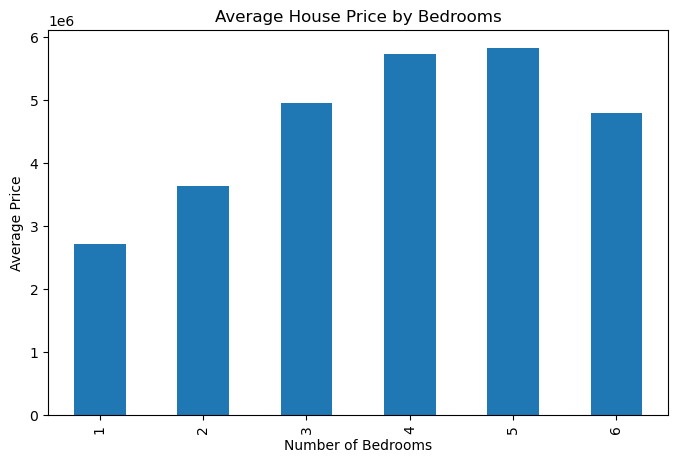

In [38]:
#Average House Price by Number of Bedrooms
avg_price = df.groupby("bedrooms")["price"].mean()

plt.figure(figsize=(8,5))

avg_price.plot(kind="bar")

plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")
plt.title("Average House Price by Bedrooms")

plt.savefig("price_by_bedrooms.png")

plt.show()

In [39]:
#Task 5 — Insights & Summary

# Task 5: Insights and Summary

#Insights

1. Features such as area, bathrooms, air conditioning, and preferred area have a strong influence on house prices.

2. Linear Regression performed better than Random Forest Regressor. It achieved an R² score of 0.653, meaning it explained about 65.3% of the variation in house prices.

3. The average prediction error was approximately ₹970,043. Although not perfect, the model provides reasonably accurate house price predictions.

4. One surprising observation was that Linear Regression outperformed Random Forest on this dataset, despite Random Forest generally being considered a more powerful model.

5. Based on the analysis, real estate businesses should focus on larger houses with better amenities and preferred locations because these features contribute significantly to higher house prices.

#Summary

This project focused on predicting house prices using machine learning techniques. The Housing Prices Dataset was loaded into Python using Pandas and explored to understand its structure and contents. The dataset contained information about various house characteristics such as area, number of bedrooms, number of bathrooms, stories, parking spaces, air conditioning, furnishing status, and other amenities. The target variable for prediction was the house price.

During the data cleaning stage, the dataset was checked for missing values and duplicate records. No missing values were found in any of the columns, and the dataset was already clean. Categorical variables such as mainroad, guestroom, basement, airconditioning, and furnishingstatus were converted into numerical form using one-hot encoding so that machine learning algorithms could process them effectively.

Two machine learning models were trained and evaluated: Linear Regression and Random Forest Regressor. The dataset was divided into training and testing sets using an 80:20 split. Linear Regression achieved a Mean Absolute Error (MAE) of approximately 970,043, a Root Mean Squared Error (RMSE) of approximately 1,324,507, and an R² Score of 0.653. Random Forest Regressor achieved an MAE of approximately 1,021,546, an RMSE of approximately 1,400,566, and an R² Score of 0.612. Based on these results, Linear Regression performed better on this dataset because it produced lower prediction errors and a higher R² score.

Several visualizations were created to better understand the data. The histogram of house prices showed the overall distribution of prices. The correlation heatmap highlighted the relationships between features and house price. Additional charts such as Price vs Area and Average Price by Bedrooms provided further insights into factors affecting house values.

The analysis revealed that features such as area, number of bathrooms, air conditioning, and preferred area have a strong influence on house prices. One interesting observation was that Linear Regression outperformed Random Forest, despite Random Forest often being considered a more advanced model. Based on these findings, real estate businesses should focus on properties with larger areas and better amenities, as these factors contribute significantly to higher market value and customer demand.